Suppose a team ran 200 experiments in a year, shipped those that "won," and
added up their reported lifts. The total looked large. Later, an annual holdout
comparison showed a much smaller improvement. What happened?

Usually nothing was wrong with the individual analyses. Two issues appear when
we aggregate winners:

1. **The winner's curse.** If we keep only experiments that clear a
significance threshold, we select those whose noise happened to point upward.
Their reported lifts are biased high.
2. **Effects do not simply add.** The sum of isolated A/B lifts is not
necessarily the joint impact of shipping all of them together.

In this post I discuss two related tools: **shrinkage**, which discounts noisy
and selected estimates, and **cumulative impact**, which aggregates many
experiments into one number and clarifies when that number can be trusted. I
use small simulations so that each point is visible from scratch, with helpers
from
[experiment-utils-pd](https://pypi.org/project/experiment-utils-pd/).

Throughout, I treat shipping as more than "the primary was significant." As in
a typical launch checklist, an experiment ships only if the primary clears a
hard bar and none of several **guardrail** metrics is significantly harmful.
Shrinkage and related joint updates adjust magnitudes on that shipped set; they
do not replace the shipping rule.

```bash
pip install "experiment-utils-pd==1.5.0"
# or
uv add "experiment-utils-pd==1.5.0"
```


## A portfolio of experiments

Most experiments have small effects. A few help, a few hurt, and every lift is
measured with noise. I also simulate five **guardrail** metrics whose true
effects are correlated with the primary (heterogeneous $$\rho$$ from 0.05 to
0.45), for example revenue, retention, or engagement. Because this is a
simulation, we know the true effects and can compare each method against them.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from experiment_utils.shrinkage import (
    cumulative_impact,
    empirical_bayes_shrinkage,
    estimate_guardrail_rho,
    fit_t_prior_with_estimated_mean,
    nss_adjusted_cumulative_impact,
    nss_adjusted_cumulative_impact_mvn,
    t_prior_shrinkage,
)

pd.set_option("display.notebook_repr_html", False)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

rng = np.random.default_rng(20260815)

# --- A world of experiments (relative lifts, in %) ---
n_exp = 200
n_guards = 5
alpha_ship = 0.10
z_crit = norm.ppf(1.0 - alpha_ship / 2.0)   # two-sided hard bar (~1.645)

tau = 0.8          # spread of true primary effects
mu_true = 0.3      # portfolio helps a little on average
true_effect = rng.normal(mu_true, tau, n_exp)

se = rng.uniform(0.8, 2.5, n_exp)
observed = true_effect + rng.normal(0, se)

# Guardrails: true effects correlated with the primary (heterogeneous rho).
rhos = np.linspace(0.05, 0.45, n_guards)
true_guards = np.column_stack([
    rho * true_effect + tau * np.sqrt(1.0 - rho**2) * rng.normal(0, 1, n_exp)
    for rho in rhos
])
se_guards = rng.uniform(0.8, 2.5, size=(n_exp, n_guards))
obs_guards = true_guards + rng.normal(0, se_guards)

exp = pd.DataFrame({"true_effect": true_effect, "observed": observed, "se": se})
exp["z"] = exp["observed"] / exp["se"]
print(exp.head())
print(f"\nGuardrail correlations with primary (true): {np.round(rhos, 2)}")
print(f"Portfolio truth: mean true effect = {true_effect.mean():.2f}%")
print(f"Mean observed effect (all 200)     = {observed.mean():.2f}%")


Matplotlib is building the font cache; this may take a moment.


   true_effect  observed    se      z
0        0.502     0.607 1.381  0.440
1        0.738     0.083 1.635  0.051
2        0.356     0.739 1.052  0.702
3        0.153    -5.826 1.833 -3.179
4        0.167    -0.491 1.761 -0.279

Guardrail correlations with primary (true): [0.05 0.15 0.25 0.35 0.45]
Portfolio truth: mean true effect = 0.38%
Mean observed effect (all 200)     = 0.42%


## The shipping rule

An experiment ships only if both conditions hold:

1. **Primary:** the effect is beneficial and two-sided significant at
$$\alpha = 0.10$$ ($$z > 1.645$$).
2. **Guardrails:** none of the five companions is significantly harmful
($$z_g < -1.645$$).

This rule decides which experiments enter the stack. Shrinkage is applied later
to magnitudes on the same shipped set.


In [2]:
primary_win = exp["z"].values > z_crit
z_guards = obs_guards / se_guards
guard_harm = z_guards < -z_crit                    # any significant harm?
blocked_by_guards = primary_win & guard_harm.any(axis=1)
shipped = primary_win & ~guard_harm.any(axis=1)

exp["primary_win"] = primary_win
exp["shipped"] = shipped
winners = exp[exp["shipped"]]

funnel = pd.DataFrame({
    "count": [n_exp, int(primary_win.sum()), int(blocked_by_guards.sum()),
              int(shipped.sum())],
}, index=["experiments", "primary hard wins", "blocked by guardrails", "shipped"])
print(funnel, "\n")

print(f"Shipped winners' average OBSERVED lift : {winners['observed'].mean():.2f}%")
print(f"Shipped winners' average TRUE lift     : {winners['true_effect'].mean():.2f}%")
inflation = winners["observed"].mean() / winners["true_effect"].mean()
print(f"\nReported lift is {inflation:.1f}x the truth among the shipped set.")

                       count
experiments              200
primary hard wins         18
blocked by guardrails      2
shipped                   16 

Shipped winners' average OBSERVED lift : 3.84%
Shipped winners' average TRUE lift     : 0.99%

Reported lift is 3.9x the truth among the shipped set.


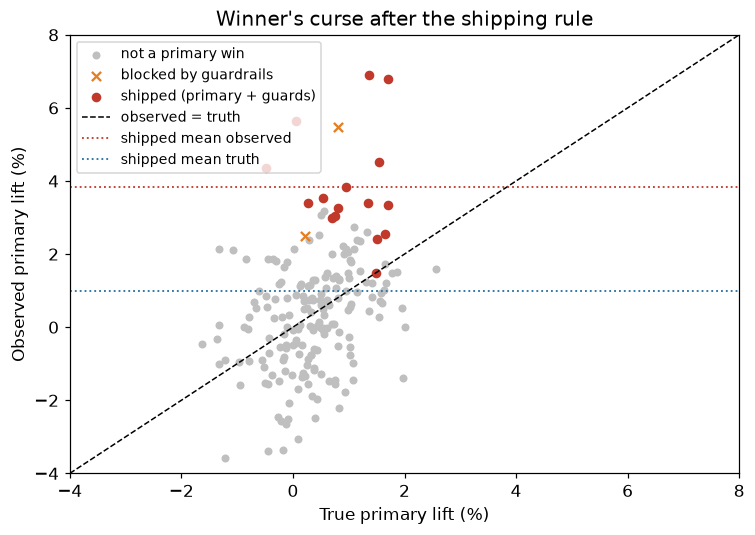

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(exp.loc[~exp["primary_win"], "true_effect"],
           exp.loc[~exp["primary_win"], "observed"],
           s=18, color="0.75", label="not a primary win")
ax.scatter(exp.loc[blocked_by_guards, "true_effect"],
           exp.loc[blocked_by_guards, "observed"],
           s=36, marker="x", color="#e67e22", label="blocked by guardrails")
ax.scatter(winners["true_effect"], winners["observed"],
           s=28, color="#c0392b", label="shipped (primary + guards)")
lims = [-4, 8]
ax.plot(lims, lims, "k--", lw=1, label="observed = truth")
ax.axhline(winners["observed"].mean(), color="#c0392b", lw=1.2, ls=":",
           label="shipped mean observed")
ax.axhline(winners["true_effect"].mean(), color="#2471a3", lw=1.2, ls=":",
           label="shipped mean truth")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True primary lift (%)"); ax.set_ylabel("Observed primary lift (%)")
ax.set_title("Winner's curse after the shipping rule")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## Shrinkage

Even after guardrails reduce the shipped set, those experiments are still
selected on a noisy primary. **Shrinkage** pulls each observed estimate toward
the archive average, and more strongly when the estimate is noisier.

With a normal prior $$\theta_i \sim \mathcal{N}(\mu, \tau^2)$$ and
$$x_i \sim \mathcal{N}(\theta_i, s_i^2)$$,

$$\tilde{\theta}_i = \mu + B_i\,(x_i - \mu), \qquad B_i = \frac{\tau^2}{\tau^2 + s_i^2}$$

Experiment archives often have fat tails, so a Student-t prior is a better
default (Azevedo et al., 2020). I fit that prior on all experiments before
selection, and then shrink the estimates.


In [4]:
t_prior = fit_t_prior_with_estimated_mean(
    exp["observed"].values, exp["se"].values, df=4.0
)

print(
    f"Fitted t-prior:  mu = {t_prior['prior_mean']:.2f}%  "
    f"[{t_prior['prior_mean_ci_lower']:.2f}, {t_prior['prior_mean_ci_upper']:.2f}]  "
    f"scale = {t_prior['scale']:.2f}  df = {t_prior['df']:.0f}"
)
print(f"(true values were mu = {mu_true:.2f}%   tau = {tau:.2f}%)\n")

shrunk = t_prior_shrinkage(
    exp["observed"].values,
    exp["se"].values,
    scale=t_prior["scale"],
    df=t_prior["df"],
    prior_mean=t_prior["prior_mean"],
)
exp["shrunk"] = shrunk["shrunk"]
exp["B"] = shrunk["shrinkage_factor"]

eb = empirical_bayes_shrinkage(
    exp["observed"].values, exp["se"].values, prior_mean=t_prior["prior_mean"]
)
exp["shrunk_eb"] = eb["shrunk"]

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

print("Accuracy vs the known truth (all 200 experiments):")
print(f"  RMSE of raw observed : {rmse(exp['observed'], exp['true_effect']):.2f}")
print(f"  RMSE of t-prior      : {rmse(exp['shrunk'],   exp['true_effect']):.2f}")
print(f"  RMSE of normal EB    : {rmse(exp['shrunk_eb'], exp['true_effect']):.2f}")

Fitted t-prior:  mu = 0.37%  [0.17, 0.60]  scale = 0.44  df = 4
(true values were mu = 0.30%   tau = 0.80%)

Accuracy vs the known truth (all 200 experiments):
  RMSE of raw observed : 1.75
  RMSE of t-prior      : 0.70
  RMSE of normal EB    : 0.69


The gain from shrinkage is clearest on the shipped set, where selection is
strongest.


In [5]:
w = exp[exp["shipped"]]
summary = pd.DataFrame({
    "mean lift (%)": [w["observed"].mean(), w["shrunk"].mean(),
                      w["shrunk_eb"].mean(), w["true_effect"].mean()],
    "RMSE vs truth": [rmse(w["observed"], w["true_effect"]),
                      rmse(w["shrunk"],   w["true_effect"]),
                      rmse(w["shrunk_eb"], w["true_effect"]), 0.0],
}, index=["observed (reported)", "t-prior shrunk", "normal EB", "true"])
print(summary, "\n")

retained = w["shrunk"].mean() / w["observed"].mean()
print(f"t-prior shrinkage retains {retained:.0%} of the shipped reported mean lift.")
print(f"Average t-prior shrinkage factor among shipped: B = {w['B'].mean():.2f}")

                     mean lift (%)  RMSE vs truth
observed (reported)          3.843          3.280
t-prior shrunk               0.852          0.606
normal EB                    0.966          0.598
true                         0.994          0.000 

t-prior shrinkage retains 22% of the shipped reported mean lift.
Average t-prior shrinkage factor among shipped: B = 0.15


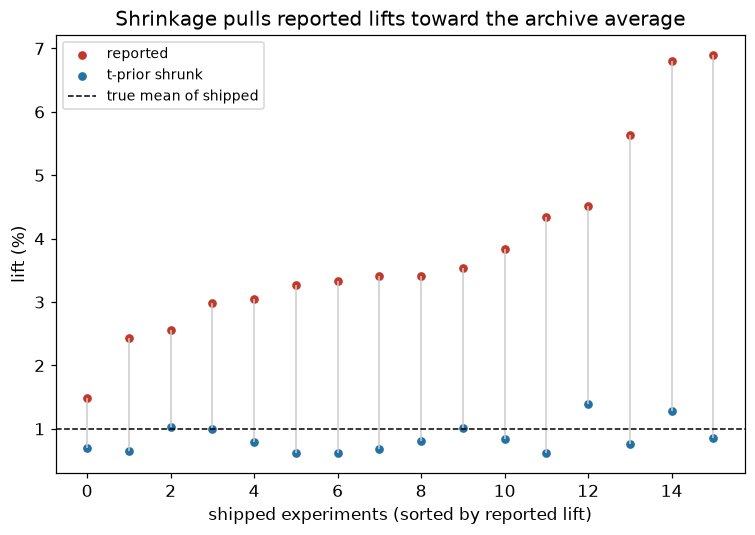

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
order = w.sort_values("observed").reset_index(drop=True)
xpos = np.arange(len(order))
ax.vlines(xpos, order["shrunk"], order["observed"], color="0.8", lw=1)
ax.scatter(xpos, order["observed"], s=22, color="#c0392b", label="reported")
ax.scatter(xpos, order["shrunk"], s=22, color="#2471a3", label="t-prior shrunk")
ax.axhline(order["true_effect"].mean(), color="k", ls="--", lw=1,
           label="true mean of shipped")
ax.set_xlabel("shipped experiments (sorted by reported lift)")
ax.set_ylabel("lift (%)")
ax.set_title("Shrinkage pulls reported lifts toward the archive average")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Cumulative impact

A natural question is how much the program moved the metric overall. One
summary is the cumulative impact of the shipped experiments:

$$\text{cumulative impact} = \sum_{i \in \text{shipped}} w_i\,\theta_i$$

`cumulative_impact` shrinks every experiment with an archive prior and then
aggregates only the shipped set. The shipping rule — primary significance and
guardrails — is passed through the `shipped` argument.

When companions are correlated with the primary, we can also borrow strength
for magnitudes, without changing who shipped:

- `nss_adjusted_cumulative_impact` uses one companion (here the one with the
largest true $$|\rho|$$).
- `nss_adjusted_cumulative_impact_mvn` uses a joint Multivariate Normal over
all five guardrails (`rho_guardrails="factor"`).


In [7]:
naive_stack = float(w["observed"].sum())
true_stack = float(w["true_effect"].sum())

cum_t = cumulative_impact(
    exp["observed"].values,
    exp["se"].values,
    shipped=exp["shipped"].values,
    prior=t_prior,
    aggregation="sum",
)

cum_eb = cumulative_impact(
    exp["observed"].values,
    exp["se"].values,
    shipped=exp["shipped"].values,
    prior_mean=t_prior["prior_mean"],
    aggregation="sum",
)

# NSS pick-one: companion with largest |rho| (known here from the DGP).
best_k = int(np.argmax(np.abs(rhos)))
cum_nss = nss_adjusted_cumulative_impact(
    exp["observed"].values,
    exp["se"].values,
    obs_guards[:, best_k],
    se_guards[:, best_k],
    shipped=exp["shipped"].values,
    rho=float(rhos[best_k]),
    prior_sd_primary=float(np.sqrt(eb["tau2"])),
    prior_sd_guard=float(np.sqrt(eb["tau2"])),
    prior_mean_primary=t_prior["prior_mean"],
    aggregation="sum",
)


# NSS MVN: joint shrink with all K companions (magnitude only).
cum_mvn = nss_adjusted_cumulative_impact_mvn(
    exp["observed"].values,
    exp["se"].values,
    obs_guards,
    se_guards,
    shipped=exp["shipped"].values,
    rho_primary=rhos,
    prior_sd_primary=float(np.sqrt(eb["tau2"])),
    prior_sd_guard=float(np.sqrt(eb["tau2"])),
    prior_mean_primary=t_prior["prior_mean"],
    rho_guardrails="factor",
    aggregation="sum",
)

stack = pd.DataFrame({
    "cumulative impact (pp)": [
        naive_stack, cum_t["cumulative"], cum_eb["cumulative"],
        cum_nss["cumulative"], cum_mvn["cumulative"], true_stack,
    ],
    "% of naive": [
        100,
        100 * cum_t["cumulative"] / naive_stack,
        100 * cum_eb["cumulative"] / naive_stack,
        100 * cum_nss["cumulative"] / naive_stack,
        100 * cum_mvn["cumulative"] / naive_stack,
        100 * true_stack / naive_stack,
    ],
}, index=[
    "naive (reported)",
    "t-prior (primary-only)",
    "normal EB (primary-only)",
    f"NSS pick-one (rho={rhos[best_k]:.2f})",
    "NSS MVN (all 5 guards)",
    "true additive",
])
print(stack)
print(
    f"\nSame ship mask for every stack: n_shipped = {cum_t['n_shipped']}  "
    f"(primary wins {int(primary_win.sum())}, "
    f"blocked by guards {int(blocked_by_guards.sum())})"
)
print(
    f"t-prior 95% CI: [{cum_t['ci_lower']:.1f}, {cum_t['ci_upper']:.1f}]  "
    f"pick-one: [{cum_nss['ci_lower']:.1f}, {cum_nss['ci_upper']:.1f}]  "
    f"MVN: [{cum_mvn['ci_lower']:.1f}, {cum_mvn['ci_upper']:.1f}]"
)


                          cumulative impact (pp)  % of naive
naive (reported)                          61.489     100.000
t-prior (primary-only)                    13.627      22.161
normal EB (primary-only)                  15.456      25.137
NSS pick-one (rho=0.45)                   15.618      25.400
NSS MVN (all 5 guards)                    15.917      25.886
true additive                             15.898      25.854

Same ship mask for every stack: n_shipped = 16  (primary wins 18, blocked by guards 2)
t-prior 95% CI: [7.8, 19.5]  pick-one: [10.6, 20.7]  MVN: [11.0, 20.9]


## Cumulative impact is not a holdout

Shrinkage, and the NSS variants above, correct selection and noise in
*marginal* lifts. A holdout answers a different question: what did the joint
product do relative to a baseline that received none of the shipped changes?

The two quantities agree when effects add. They diverge under interference,
cannibalization, saturation, or related general-equilibrium shifts. NSS cannot
close that gap, because it does not model interference across experiments.

I simulate additive and sub-additive worlds under the same shipping rule
(primary plus five guardrails). For speed across Monte Carlo replicates, I use
`cumulative_impact` with a normal empirical-Bayes prior.


In [8]:
def one_world(rng, delta):
    """One portfolio under the primary + guardrail ship gate."""
    te = rng.normal(mu_true, tau, n_exp)
    s = rng.uniform(0.8, 2.5, n_exp)
    x = te + rng.normal(0, s)

    tg = np.column_stack([
        rho * te + tau * np.sqrt(1.0 - rho**2) * rng.normal(0, 1, n_exp)
        for rho in rhos
    ])
    sg = rng.uniform(0.8, 2.5, size=(n_exp, n_guards))
    xg = tg + rng.normal(0, sg)

    primary_ok = (x / s) > z_crit
    guard_ok = ~((xg / sg) < -z_crit).any(axis=1)
    shipped = primary_ok & guard_ok

    if shipped.sum() < 1:
        return None

    mu_hat = float(np.average(x, weights=1.0 / s**2))
    cum = cumulative_impact(
        x, s, shipped=shipped, prior_mean=mu_hat, aggregation="sum"
    )

    a = te[shipped]
    L = float(a.sum())
    share = 1 - (np.sum(a**2) / L**2) if L != 0 else 0.0
    holdout_sub = L * (1 - delta * share)

    return {
        "naive": float(x[shipped].sum()),
        "shrunk": float(cum["cumulative"]),
        "oracle": L,
        "holdout_add": L,
        "holdout_sub": holdout_sub,
        "n_primary": int(primary_ok.sum()),
        "n_blocked": int((primary_ok & ~guard_ok).sum()),
        "n_shipped": int(shipped.sum()),
    }

n_mc, delta = 2000, 0.30
rows = [one_world(np.random.default_rng(s), delta) for s in range(n_mc)]
sim = pd.DataFrame([r for r in rows if r is not None])

print("Scale-rule funnel (means across MC worlds)")
print(sim[["n_primary", "n_blocked", "n_shipped"]].mean().round(2), "\n")

def bias_row(est, truth):
    d = sim[est] - sim[truth]
    return [sim[est].mean(), d.mean(), d.abs().mean()]

print("ADDITIVE world  (holdout = sum of true parts)")
add = pd.DataFrame(
    [bias_row("naive", "holdout_add"),
     bias_row("shrunk", "holdout_add"),
     bias_row("oracle", "holdout_add")],
    columns=["mean stack (pp)", "bias vs holdout", "mean |error|"],
    index=["naive", "cumulative_impact (EB)", "oracle"])
print(add, "\n")

print(f"SUB-ADDITIVE world  (delta = {delta}: joint < sum of parts)")
sub = pd.DataFrame(
    [bias_row("naive", "holdout_sub"),
     bias_row("shrunk", "holdout_sub"),
     bias_row("oracle", "holdout_sub")],
    columns=["mean stack (pp)", "bias vs holdout", "mean |error|"],
    index=["naive", "cumulative_impact (EB)", "oracle"])
print(sub)
print(f"\nJoint holdout is on average "
      f"{100 * sim['holdout_sub'].mean() / sim['holdout_add'].mean():.0f}% "
      f"of the additive sum.")

Scale-rule funnel (means across MC worlds)
n_primary   20.850
n_blocked    5.260
n_shipped   15.590
dtype: float64 

ADDITIVE world  (holdout = sum of true parts)
                        mean stack (pp)  bias vs holdout  mean |error|
naive                            51.969           36.347        36.347
cumulative_impact (EB)           15.130           -0.493         3.520
oracle                           15.622            0.000         0.000 

SUB-ADDITIVE world  (delta = 0.3: joint < sum of parts)
                        mean stack (pp)  bias vs holdout  mean |error|
naive                            51.969           40.582        40.582
cumulative_impact (EB)           15.130            3.742         4.636
oracle                           15.622            4.235         4.242

Joint holdout is on average 73% of the additive sum.


Two points stand out:

- In the **additive** world, the naive stack is badly inflated, while
`cumulative_impact` is close to the holdout and the oracle.
- In the **sub-additive** world, even the oracle overstates the holdout.
Guardrails and NSS joint shrinkage do not model interference across shipped
experiments, so they cannot close that gap.


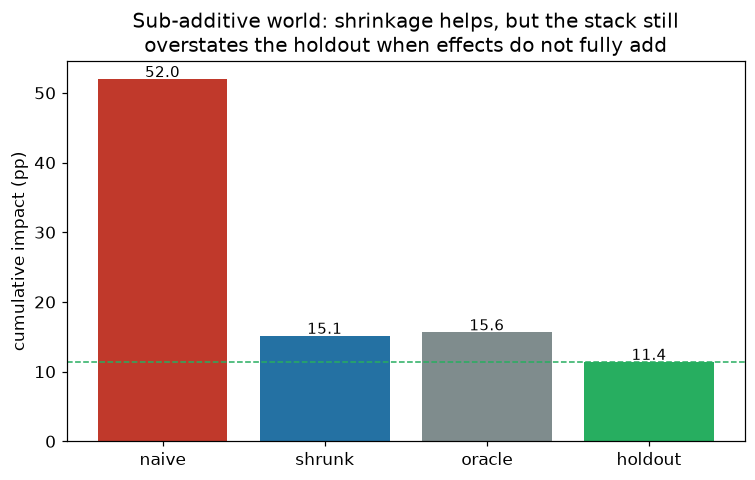

In [9]:
labels = ["naive", "shrunk", "oracle", "holdout"]
means = [sim["naive"].mean(), sim["shrunk"].mean(), sim["oracle"].mean(),
         sim["holdout_sub"].mean()]
colors = ["#c0392b", "#2471a3", "#7f8c8d", "#27ae60"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, means, color=colors)
ax.axhline(sim["holdout_sub"].mean(), color="#27ae60", ls="--", lw=1)
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.3, f"{m:.1f}",
            ha="center", fontsize=10)
ax.set_ylabel("cumulative impact (pp)")
ax.set_title("Sub-additive world: shrinkage helps, but the stack still\n"
             "overstates the holdout when effects do not fully add")
plt.tight_layout()
plt.show()


## Takeaways

- The shipped set should follow the full checklist: primary significance and no
significant guardrail harm. That is the set we aggregate, not every experiment
with a significant primary.
- Even after guardrails, selection on a noisy primary biases reported lifts
upward.
- Shrinkage helps. Fit an archive prior with
`fit_t_prior_with_estimated_mean`, shrink with `t_prior_shrinkage`, or pass the
prior to `cumulative_impact`. When companions are informative, use
`nss_adjusted_cumulative_impact` or `nss_adjusted_cumulative_impact_mvn` for
magnitudes. These tools do not replace the shipping rule.
- Cumulative impact and a global holdout are different estimands. They agree
when effects add and diverge under interference. NSS does not solve that
problem.

Shrinkage and cumulative impact make reported numbers more honest. They do not
replace careful design or a periodic holdout.

<br>

***

## References

- Azevedo, E. M. et al. *A/B Testing with Fat Tails.* Journal of Political
Economy, 2020.
- Efron, B. & Morris, C. *Stein's Paradox in Statistics.* Scientific American,
1977.
- Kessler, R. / Datadog. Noise-adjusted cumulative impact of shipped
experiments (see `cumulative_impact` /
`nss_adjusted_cumulative_impact` /
`nss_adjusted_cumulative_impact_mvn` in
[experiment-utils-pd](https://pypi.org/project/experiment-utils-pd/)).
- Kohavi, R., Tang, D. & Xu, Y. *Trustworthy Online Controlled Experiments.*
- Lee, M. & Shen, M. *Winner's Curse: Bias Estimation for Total Effects of
Features in Online Controlled Experiments.* KDD, 2018.
